# ผู้เข้าแข่งขันรหัส 600659 รัชพล สม่าหลี

สามารถดู <u>**Notebook ฉบับสมบูรณ์**</u>ได้จาก

https://colab.research.google.com/drive/18q8a5aPbCkCLyl0dPwZcYDPB0o_R577d?usp=sharing
---

ผมได้แบ่ง Markdown ไว้แล้ว สามารถเปิดใช้ Table of contents ของ colab เพื่อให้การตรวจทำได้ง่ายขึ้นได้ครับ

# การวิเคราะห์คุณภาพของรูปที่เก็บรวบรวมมา (EDA)
Notebook นี้จะทำการวิเคราะห์รูปภาพเอกสารทั้งหมดในโฟลเดอร์ นำข้อมูลทางสถิติของแต่ละภาพมาวิเคราะห์ภาพรวม (Aggregate) เพื่อดูแนวโน้มว่าทั้งดาต้าเซ็ตมีปัญหา DPI ต่ำ เบลอหรือมัว มืดเกินไป หรือมีจุดรบกวนมากน้อยแค่ไหน

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

IMAGE_DIR = "./data/images" # เปลี่ยนให้ตรงกับโฟลเดอร์ภาพของคุณ
image_paths = glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) + \
              glob.glob(os.path.join(IMAGE_DIR, "*.png")) + \
              glob.glob(os.path.join(IMAGE_DIR, "*.jpeg"))

print(f"Found {len(image_paths)} images for EDA.")

Found 846 images for EDA.


## 1. การดึงข้อมูลเมทริกซ์จากแต่ละรูปภาพ
ลูปอ่านภาพทั้งหมดเพื่อดึงค่า:
- **DPI & Size** จาก Metadata
- **Blur (Laplacian Variance)**
- **Darkness (Mean Intensity):** พิจารณาเพียงแค่ภาพมืดเกินไป เนื่องจากเอกสารมีพื้นหลังาีขาว
- **Noise Level** หาค่า Absolute Difference ของภาพที่ตรวจสอบ แล้วภาพที่นำไปกัดจ Noise --> นำค่าที่ได้ทุกรูปมาหาค่าเฉลี่ย

In [ ]:
results = []
for path in image_paths:
    filename = os.path.basename(path)
    image = cv2.imread(path)
    if image is None: continue
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 1. Resolution Check (DPI/Size)
    dpi, w, h = None, None, None
    try:
        with Image.open(path) as img:
            dpi = img.info.get('dpi', (None, None))[0]
            w, h = img.size
    except:
        pass

    # 2. Blur Detection
    variance = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 3. Exposure (Darkness Check - since background is white)
    mean_intensity = np.mean(gray)

    # 4. Noise & Artifacts
    filtered = cv2.medianBlur(gray, 5)
    noise_level = np.mean(cv2.absdiff(gray, filtered))

    results.append({
        'Filename': filename,
        'DPI': dpi if dpi else np.nan,
        'Width': w,
        'Height': h,
        'Laplacian_Variance': variance,
        'Mean_Intensity': mean_intensity,
        'Noise_Level': noise_level
    })

df = pd.DataFrame(results)
if not df.empty:
    # แสดงข้อมูลทางสถิติโดยรวมของทั้ง Dataset
    display(df.describe().round(2))
else:
    print("ไม่มีรูปภาพในโฟลเดอร์ให้วิเคราะห์ กรุณาเพิ่มรูปก่อนรันเซลล์ถัดไป")

,DPI,Width,Height,Laplacian_Variance,Mean_Intensity,Noise_Level
count,0.0,846.00,846.00,846.00,846.00,846.00
mean,NaN,2480.09,3507.25,2086.99,245.82,1.63
std,NaN,1.04,2.17,808.55,3.35,0.58
min,NaN,2480.00,3507.00,56.25,234.51,0.21
25%,NaN,2480.00,3507.00,1565.07,243.95,1.32
50%,NaN,2480.00,3507.00,2107.77,246.11,1.62
75%,NaN,2480.00,3507.00,2649.28,247.85,2.01
max,NaN,2500.00,3530.00,4434.32,253.80,3.44


## 2. พลอตกราฟแจกแจง (Global EDA Visualizations)

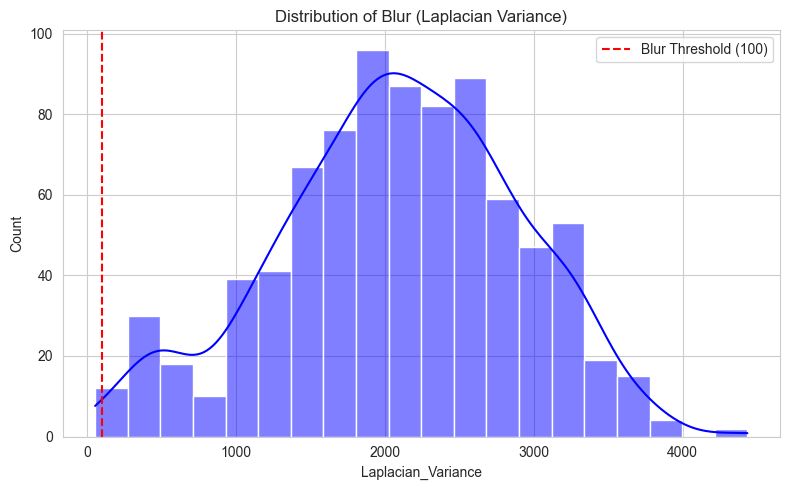

In [ ]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.set_style("whitegrid")

    sns.histplot(data=df, x='Laplacian_Variance', kde=True, ax=ax, color='blue')
    ax.axvline(100, color='red', linestyle='--', label='Blur Threshold (100)')
    ax.set_title('Distribution of Blur (Laplacian Variance)')
    ax.legend()

    plt.tight_layout()
    plt.show()

- มี่รูปเพียงเล็กน้อยที่มีความเบลอแย่กว่าค่าที่รับได้ที่ได้กำหนดไว้

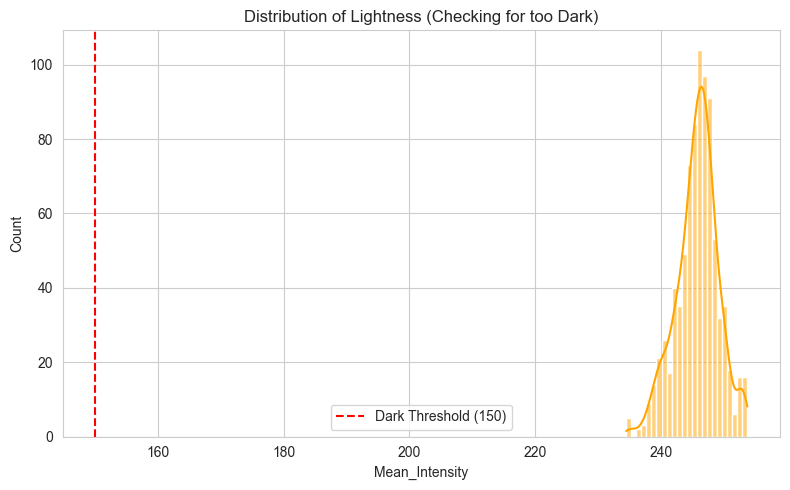

In [ ]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.set_style("whitegrid")

    sns.histplot(data=df, x='Mean_Intensity', kde=True, ax=ax, color='orange')
    ax.axvline(150, color='red', linestyle='--', label='Dark Threshold (150)')
    ax.set_title('Distribution of Lightness (Checking for too Dark)')
    ax.legend()

    plt.tight_layout()
    plt.show()

- ไม่มีรูปใดที่มืดเกินไป

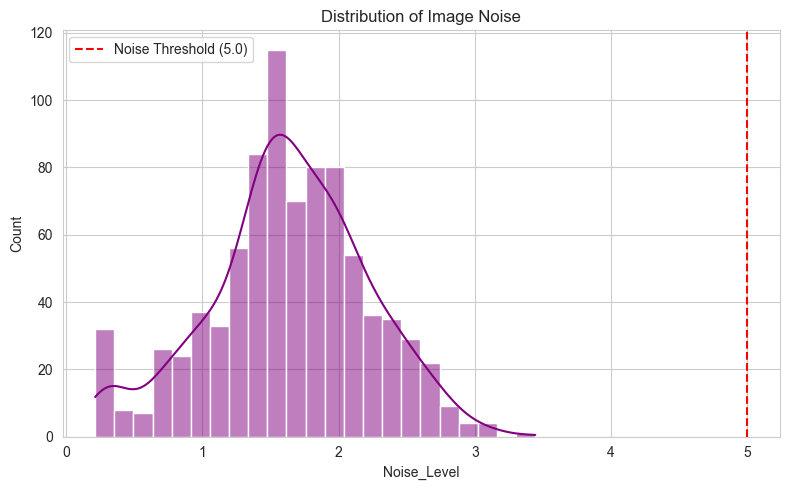

In [ ]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.set_style("whitegrid")

    sns.histplot(data=df, x='Noise_Level', kde=True, ax=ax, color='purple')
    ax.axvline(5, color='red', linestyle='--', label='Noise Threshold (5.0)')
    ax.set_title('Distribution of Image Noise')
    ax.legend()

    plt.tight_layout()
    plt.show()

- ไม่มีภาพใดที่ภาพมีสิ่งรบกวนมากกว่าที่ได้กำหนดไว้

## 3. สรุปภาพรวมและประเด็นที่พบ (Dataset Quality Summary)

In [ ]:
if not df.empty:
    print("="*50)
    print("รายงานภาพรวมคุณภาพรูปภาพทั้งหมด (Dataset Quality Report)")
    print("="*50)

    # นับ DPI ที่อาจจะมีปัญหา
    if df['DPI'].notna().any():
        low_dpi = (df['DPI'] < 150).sum()
        print(f"- พบภาพที่มี DPI ต่ำกว่า 150: {low_dpi} ภาพ จาก {len(df)} ภาพ")
    else:
        low_res = ((df['Width'] < 1200) | (df['Height'] < 1200)).sum()
        print(f"- ไม่พบค่า DPI ในรูปภาพ แต่พบภาพที่มีขนาดพิกเซลเล็กเกินไป: {low_res} ภาพ จาก {len(df)} ภาพ")

    # ภาพที่เบลอ
    blurry = (df['Laplacian_Variance'] < 100).sum()
    print(f"- ภาพที่มีแนวโน้มเบลอ (Variance < 100): {blurry} ภาพ ({(blurry/len(df))*100:.1f}%)")

    # ภาพที่มืดเกินไป
    dark = (df['Mean_Intensity'] < 150).sum()
    print(f"- ภาพที่มีแนวโน้มมืดเกินไป (Mean Intensity < 150): {dark} ภาพ ({(dark/len(df))*100:.1f}%)")


    # ภาพที่มี Noise มาก
    noisy = (df['Noise_Level'] > 5.0).sum()
    print(f"- ภาพที่มีจุดรบกวน/Noise สูง: {noisy} ภาพ ({(noisy/len(df))*100:.1f}%)")

    print("\n--- ภาพที่ควรตรวจสอบเพิ่มเติม (Worst Cases) ---")
    # แสดงชื่อไฟล์ที่มีปัญหาหนักในแต่ละด้าน
    worst_blur = df.sort_values(by='Laplacian_Variance').head(1)
    print(f"=> ภาพที่เบลอที่สุด: {worst_blur['Filename'].values[0]} (Variance: {worst_blur['Laplacian_Variance'].values[0]:.2f})")

    worst_dark = df.sort_values(by='Mean_Intensity').head(1)
    print(f"=> ภาพที่มืดที่สุด: {worst_dark['Filename'].values[0]} (Intensity: {worst_dark['Mean_Intensity'].values[0]:.2f})")



รายงานภาพรวมคุณภาพรูปภาพทั้งหมด (Dataset Quality Report)
- ไม่พบค่า DPI ในรูปภาพ แต่พบภาพที่มีขนาดพิกเซลเล็กเกินไป: 0 ภาพ จาก 846 ภาพ
- ภาพที่มีแนวโน้มเบลอ (Variance < 100): 4 ภาพ (0.5%)
- ภาพที่มีแนวโน้มมืดเกินไป (Mean Intensity < 150): 0 ภาพ (0.0%)
- ภาพที่มีจุดรบกวน/Noise สูง: 0 ภาพ (0.0%)

--- ภาพที่ควรตรวจสอบเพิ่มเติม (Worst Cases) ---
=> ภาพที่เบลอที่สุด: party_list_10_24_page6.png (Variance: 56.25)
=> ภาพที่มืดที่สุด: party_list_10_24.png (Intensity: 234.51)


พบว่ารูปภาพที่ได้มา โดยรวม
- ไม่มีปัญหาเรื่องความชัด (Dataset ระบุว่า DPI 300 และตรวจสอบ dimension ภาพก็มีขนาดใหญ่)
- มีภาพเล็กน้อยที่เกิดปัญหาเบลอ จากการตรวจสอบ สาเหตุมาจาก จุดดำจากการถ่ายเอกสาร
- ไม่มีภาพที่มืดเกินไป
- ไม่มีภาพที่มี Noise สูง
- เมื่อตรวจสอบภาพ Worst case พบว่าความเบลอและความมืดมาจากรอยดำจากการแสกน

<u>**Note**</u> ผู้ทำขาดความรู้ด้าน image preprocessing จึงขอข้ามการปรับปรุงคุณภาพข้อมูลรูปภาพเหล่านี้ เพื่อให้สามารถ submit ทันในวันอาทิตย์ที่ 22 มีนาคม 69 เนื่องจากไม่มีเวลาเพียงพอสำหรับการศึกษาเพิ่มเติม และจากการใช้ gemini 3 flash มา OCR ในชีวิตประจำวัน คาดว่าตัวโมเดลมีประสิทธิภาพในการรับมือกับปัญหาที่พบจากการ EDA ในระดับหนึ่ง

# โมเดลที่ใช้ Gemini 3 flash

### **Note** โค้ดนี้มีการใช้ python script ร่วมด้วยเนื่องจากผมเข้าใจว่าไม่ต้องส่ง google colab อย่างไรก็ตามโน้ตบุ๊คนี้ได้ระบุรายละเอียดไว้ครบถ้วน หากต้องการเข้าถึง .py script อื่นๆสามารถดูได้จาก <u>**`ส่วนท้ายของไฟล์`**</u>

<br>

### นอกจากนี้ Jupyter นี้เขียนแยกกันในตอนแรก แต่ถูกนำมารวมกันในภายหลังเพื่อใช้ประกอบการส่งงานด้วย Colab


# โครงสร้างของ Notebook oี้
  1. OCR pipeline ของรูปเอกสารผลการเลือกตั้งแบ่งเขต
  2. OCR pipeline ของรูปเอกสารผลการเลือกตั้งบัญชีรายชื่อ
  3. นำผลที่เก็บในรูป ตาราง Markdown เก็บไว้ใน `ชื่อเอกสาร.md` มาแปลงเป็นไฟล์ CSV

## 🗳️ Election OCR Pipeline (Gemini Edition)
วิธีทำ : กรองชื่อ doc จากชื่อไฟล์รูปภาพตาม `submission_template_v3.csv` และส่งภาพทุกหน้าไปให้ Gemini-3-flash ประมวลผลออกมาเป็นไฟล์ `.md` ลงในโฟลเดอร์ `output/` โดยอัตโนมัติ โดยจะส่งเข้าไปหลายๆรูป(หลายหน้าของเอกสาร) แต่จะส่งทีละเอกสาร โดย output จาก Gemini-3-flash จะส่งผลลัพธ์ออกมาเป็น markdown ตารางเก็บไว้ในไฟล์ `ชื่อเอกสารผลเลือกตั้ง (doc id).md`

### **การ OCR จะดึงข้อมูลมาจากข้อความเท่านั้นแล้วแปลงเป็นเลขอารบิกเนื่องจากผู้ทำมีสมมติฐานว่าเชื่อถือได้มากกว่าตัวเลขไทย**

In [ ]:
import os
import sys
import datetime

# เพิ่ม Path โฟลเดอร์ pipeline เพื่อให้ระบบมองเห็น
sys.path.append(os.path.abspath("../pipeline"))

# นําเข้า Module ที่เราสร้างไว้
from image_loader import build_manifest
from ocr_engine import run_ocr, save_output_md

c:\Users\User\anaconda3\envs\ocr_vision_fixed\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\User\anaconda3\envs\ocr_vision_fixed\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\SAIE SS6 OCR\Con_pipeline\pipeline\ocr_engine.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more 

## แสกนหาเอกสารจากไฟล์รูป อันที่เป็น constituency

In [ ]:
# 1. สร้าง Manifest ข้อมูล (ดึงชื่อรูปมาจับคู่กับ doc_id)
doc_manifest = build_manifest()
all_doc_ids = list(doc_manifest.keys())

print(f"✅ พบเอกสารที่พร้อมสกัดข้อมูลทั้งหมด (แบบแบ่งเขต): {len(all_doc_ids)} ชุด")
print(f"📝 ตัวอย่าง 3 doc_id แรก: {all_doc_ids[:3]}")

✅ พบเอกสารที่พร้อมสกัดข้อมูลทั้งหมด (แบบแบ่งเขต): 150 ชุด
📝 ตัวอย่าง 3 doc_id แรก: ['constituency_10_1', 'constituency_10_10', 'constituency_10_11']


In [ ]:
# 2. ฟังก์ชันรันงาน (กำหนดค่าพารามิเตอร์ที่นี่)

START_INDEX = 0
LIMIT = 'All'   # ใส่เป็นตัวเลข (เช่น 5, 10) เพื่อทดลองรัน หรือใส่เป็น 'All' เพื่อรันทั้งหมดครับ

# --- 🧠 Logic การเลือกจำนวนงานที่จะรัน ---
if LIMIT == 'All':
    target_ids = all_doc_ids[START_INDEX:]
    print(f"🚀 [MODE: FULL RUN] เริ่มรันเอกสารทั้งหมด {len(target_ids)} ชุด ตั้งแต่ลำดับที่ {START_INDEX} เป็นต้นไป...")
else:
    last_idx = START_INDEX + int(LIMIT)
    target_ids = all_doc_ids[START_INDEX : last_idx]
    print(f"⏳ [MODE: TEST/LIMITED] เริ่มประมวลผล {len(target_ids)} เอกสาร ตั้งแต่ลำดับที่ {START_INDEX} ถึง {last_idx-1}...")

for idx, doc_id in enumerate(target_ids):
    # ดึงรายชื่อภาพสำหรับ doc_id นี้ (รองรับหลายหน้า)
    images = doc_manifest[doc_id]

    print(f"[{idx+1}/{len(target_ids)}] สกัดข้อมูล: {doc_id} ({len(images)} หน้า)...", end=" ")

    # 🧠 ขั้นตอน OCR ด้วย Gemini
    markdown_result = run_ocr(doc_id, images)

    # 💾 บันทึกผลลัพธ์เป็นไฟล์ .md ตั้งชื่อตาม doc_id
    save_path = save_output_md(doc_id, markdown_result)

    print(f"✅ บันทึกเสร็จที่: output/{os.path.basename(save_path)}")

print("\n🏁 *** สิ้นสุดการรันตามจำนวนที่กำหนด ***")

🚀 [MODE: FULL RUN] เริ่มรันเอกสารทั้งหมด 150 ชุด ตั้งแต่ลำดับที่ 0 เป็นต้นไป...
[1/150] สกัดข้อมูล: constituency_10_1 (3 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_1.md
[2/150] สกัดข้อมูล: constituency_10_10 (2 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_10.md
[3/150] สกัดข้อมูล: constituency_10_11 (3 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_11.md
[4/150] สกัดข้อมูล: constituency_10_12 (3 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_12.md
[5/150] สกัดข้อมูล: constituency_10_13 (2 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_13.md
[6/150] สกัดข้อมูล: constituency_10_14 (3 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_14.md
[7/150] สกัดข้อมูล: constituency_10_16 (2 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_16.md
[8/150] สกัดข้อมูล: constituency_10_17 (2 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_17.md
[9/150] สกัดข้อมูล: constituency_10_18 (3 หน้า)... ✅ บันทึกเสร็จที่: output/constituency_10_18.md
[10/150] สกัดข้อมูล: constituency_10_19 

## หลัง OCR ผลรายเขตเสร็จสิ้น OCR บัญชีรายชื่อต่อ

## 🗳️ Election OCR Pipeline (Gemini Edition)

In [ ]:
import os
import sys
import datetime

# เพิ่ม Path โฟลเดอร์ pipeline เพื่อให้ระบบมองเห็น
sys.path.append(os.path.abspath("../pipeline"))

# นําเข้า Module ที่เราสร้างไว้
from image_loader import build_manifest
from ocr_engine import run_ocr, save_output_md

c:\Users\User\anaconda3\envs\ocr_vision_fixed\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\User\anaconda3\envs\ocr_vision_fixed\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\SAIE SS6 OCR\Party_list_pipeline\pipeline\ocr_engine.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README fo

## แสกนหาเอกสารจากไฟล์รูป อันที่เป็น party_list

In [ ]:
# 1. สร้าง Manifest ข้อมูล (ดึงชื่อรูปมาจับคู่กับ doc_id)
doc_manifest = build_manifest()
all_doc_ids = list(doc_manifest.keys())

print(f"✅ พบเอกสารที่พร้อมสกัดข้อมูลทั้งหมด (บัญชีรายชื่อ): {len(all_doc_ids)} ชุด")
print(f"📝 ตัวอย่าง 3 doc_id แรก: {all_doc_ids[:3]}")

✅ พบเอกสารที่พร้อมสกัดข้อมูลทั้งหมด (บัญชีรายชื่อ): 150 ชุด
📝 ตัวอย่าง 3 doc_id แรก: ['party_list_10_1', 'party_list_10_10', 'party_list_10_11']


In [ ]:
# 2. ฟังก์ชันรันงาน (กำหนดค่าพารามิเตอร์ที่นี่)

START_INDEX = 0
LIMIT = 'All'   # ใส่เป็นตัวเลข (เช่น 5, 10) เพื่อทดลองรัน หรือใส่เป็น 'All' เพื่อรันทั้งหมดครับ

# --- 🧠 Logic การเลือกจำนวนงานที่จะรัน ---
if LIMIT == 'All':
    target_ids = all_doc_ids[START_INDEX:]
    print(f"🚀 [MODE: FULL RUN] เริ่มรันเอกสารทั้งหมด {len(target_ids)} ชุด ตั้งแต่ลำดับที่ {START_INDEX} เป็นต้นไป...")
else:
    last_idx = START_INDEX + int(LIMIT)
    target_ids = all_doc_ids[START_INDEX : last_idx]
    print(f"⏳ [MODE: TEST/LIMITED] เริ่มประมวลผล {len(target_ids)} เอกสาร ตั้งแต่ลำดับที่ {START_INDEX} ถึง {last_idx-1}...")

for idx, doc_id in enumerate(target_ids):
    # ดึงรายชื่อภาพสำหรับ doc_id นี้ (รองรับหลายหน้า)
    images = doc_manifest[doc_id]

    print(f"[{idx+1}/{len(target_ids)}] สกัดข้อมูล: {doc_id} ({len(images)} หน้า)...", end=" ")

    # 🧠 ขั้นตอน OCR ด้วย Gemini
    markdown_result = run_ocr(doc_id, images)

    # 💾 บันทึกผลลัพธ์เป็นไฟล์ .md ตั้งชื่อตาม doc_id
    save_path = save_output_md(doc_id, markdown_result)

    print(f"✅ บันทึกเสร็จที่: output/{os.path.basename(save_path)}")

print("\n🏁 *** สิ้นสุดการรันตามจำนวนที่กำหนด ***")

🚀 [MODE: FULL RUN] เริ่มรันเอกสารทั้งหมด 150 ชุด ตั้งแต่ลำดับที่ 0 เป็นต้นไป...
[1/150] สกัดข้อมูล: party_list_10_1 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_1.md
[2/150] สกัดข้อมูล: party_list_10_10 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_10.md
[3/150] สกัดข้อมูล: party_list_10_11 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_11.md
[4/150] สกัดข้อมูล: party_list_10_12 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_12.md
[5/150] สกัดข้อมูล: party_list_10_13 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_13.md
[6/150] สกัดข้อมูล: party_list_10_14 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_14.md
[7/150] สกัดข้อมูล: party_list_10_16 (5 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_16.md
[8/150] สกัดข้อมูล: party_list_10_17 (3 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_17.md
[9/150] สกัดข้อมูล: party_list_10_18 (4 หน้า)... ✅ บันทึกเสร็จที่: output/party_list_10_18.md
[10/150] สกัดข้อมูล: party_list_10_19 (4 หน้า)... ✅ บันทึกเสร็จที่: output/p

# การรวมผลและตอบคะแนนโหวตใน csv ตาม template ที่ได้จากโจทย์

เมื่อแสกนครบทั้งผลรายเขตและบัญชีรายชื่อ แล้วเซฟเป็นไฟล์ .MD นำผลจากไฟล์ .MD เหล่านั้นมา Map โดย Map พรรคกับคะแนนโหวตให้ตรงกัน ทำแบบนี้ให้ครบทุก doc ภายใน `csv ที่จะ submit`

 หากหาเจอก็จะ Map ไปเลยตามปกติแต่หากหาชื่อพรรคที่ตรงกันไม่เจอจะใช้ Fuzzy String Matching เพื่อหาตัวที่น่าจะใช่

In [ ]:

import pandas as pd
import os
import difflib

csv_path = 'submission_template_v3.csv'
df = pd.read_csv(csv_path)

df['votes'] = 0
df['is_mapped'] = False

unmapped_issues = []

alias_map = {
    'ก้าวไกล': 'ประชาชน', 'ฟิวเจอร์': 'ฟิวชัน', 'ฟิวชั่น': 'ฟิวชัน', 'ฟิวชน': 'ฟิวชัน',
    'พรรคเพื่อชาติไทย': 'เพื่อชาติไทย', 'รวมพลังประชาขน': 'รวมพลังประชาชน',
    'เศรษฐกิจไทย': 'เศรษฐกิจ', 'ไทยสรรพเยาว์': 'ไทยสรรพเยาว',
    'เครือข่ายชาวนาแห่งประเทศไทย': 'เเครือข่ายชาวนาแห่งประเทศไทย'
}

def clean_party_name(name):
    return str(name).replace('พรรค', '').replace(' ', '').strip()

# ==========================================
# 1. ระบบประมวลผลสำหรับ Party List (แม่นยำ 100% ผ่าน "เบอร์")
# ==========================================
def process_partylist_folder(folder_path):
    if not os.path.exists(folder_path): return

    for filename in os.listdir(folder_path):
        if not filename.endswith('.md'): continue

        doc_id = filename.replace('.md', '')
        filepath = os.path.join(folder_path, filename)

        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        no_col = -1
        vote_col = -1

        for line in lines:
            line = line.strip()
            if line.startswith('|') and not line.startswith('| :---'):
                parts = [p.strip() for p in line.split('|')]

                if 'เบอร์' in line or 'คะแนน' in line:
                    for i, p in enumerate(parts):
                        if 'เบอร์' in p: no_col = i
                        elif 'คะแนน' in p: vote_col = i
                    continue

                if no_col != -1 and vote_col != -1 and len(parts) > max(no_col, vote_col):
                    try:
                        no_str = parts[no_col].strip()
                        if not no_str.isdigit(): continue
                        ber_no = int(no_str)

                        votes_str = parts[vote_col].replace(',', '').strip()
                        if votes_str == '-': votes = 0
                        elif not votes_str.isdigit(): continue
                        else: votes = int(votes_str)

                        target_id = f"{doc_id}_{ber_no}"

                        # ยัดลงช่องตาม ID ตรงๆ เลย ไม่ต้องสนชื่อตาราง OCR ที่เพี้ยน!
                        matched_idx = df.index[df['id'] == target_id].tolist()
                        if matched_idx:
                            df.at[matched_idx[0], 'votes'] = votes
                            df.at[matched_idx[0], 'is_mapped'] = True
                        else:
                            # บางทีเขียนมา 57 พรรค แต่ CSV ดันมีกรอบให้กรอกแค่ 56
                            unmapped_issues.append({'doc_id': doc_id, 'party_in_md': f"เบอร์ {ber_no}", 'votes': votes, 'reason': 'รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี'})

                    except ValueError: pass

# ==========================================
# 2. ระบบประมวลผลสำหรับ Constituency (ผ่านชื่อพรรค Two-Pass)
# ==========================================
def process_constituency_folder(folder_path):
    if not os.path.exists(folder_path): return

    for filename in os.listdir(folder_path):
        if not filename.endswith('.md'): continue

        doc_id = filename.replace('.md', '')
        filepath = os.path.join(folder_path, filename)

        csv_slice_condition = df['id'].str.startswith(f"{doc_id}_")
        csv_slice_indices = df[csv_slice_condition].index

        valid_parties_pool = []
        party_to_index_map = {}

        for idx in csv_slice_indices:
            row_id = str(df.at[idx, 'id'])
            base_doc_id = row_id.rsplit('_', 1)[0]
            if base_doc_id == doc_id:
                raw_party = df.at[idx, df.columns[1]]
                if pd.isna(raw_party) or str(raw_party).strip() == '': continue
                clean_csv_party = clean_party_name(raw_party)
                valid_parties_pool.append(clean_csv_party)
                party_to_index_map[clean_csv_party] = idx

        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        party_col = -1
        vote_col = -1
        md_entries = []

        for line in lines:
            line = line.strip()
            if line.startswith('|') and not line.startswith('| :---'):
                parts = [p.strip() for p in line.split('|')]

                if 'ชื่อพรรค' in line or 'คะแนน' in line:
                    for i, p in enumerate(parts):
                        if 'ชื่อพรรค' in p: party_col = i
                        elif 'คะแนน' in p: vote_col = i
                    continue

                if party_col != -1 and vote_col != -1 and len(parts) > max(party_col, vote_col):
                    try:
                        party_name = parts[party_col]
                        party_name_clean = clean_party_name(party_name)

                        if not party_name_clean or party_name_clean == '-': continue
                        if party_name_clean in alias_map: party_name_clean = alias_map[party_name_clean]

                        votes_str = parts[vote_col].replace(',', '').strip()
                        if votes_str == '-': votes = 0
                        elif not votes_str.isdigit(): continue
                        else: votes = int(votes_str)

                        md_entries.append({'raw': party_name, 'clean': party_name_clean, 'votes': votes})

                    except ValueError: pass

        remaining_md_entries = []
        for entry in md_entries:
            if entry['clean'] in valid_parties_pool:
                matched_idx = party_to_index_map[entry['clean']]
                # เติมได้เลย ไม่ห่วงคนแย่ง เพราะเราเอาพวกชื่อเป๊ะก่อน
                df.at[matched_idx, 'votes'] = entry['votes']
                df.at[matched_idx, 'is_mapped'] = True
                valid_parties_pool.remove(entry['clean'])
            else:
                remaining_md_entries.append(entry)

        for entry in remaining_md_entries:
            matches = difflib.get_close_matches(entry['clean'], valid_parties_pool, n=1, cutoff=0.50)
            if matches:
                best_match = matches[0]
                matched_idx = party_to_index_map[best_match]
                df.at[matched_idx, 'votes'] = entry['votes']
                df.at[matched_idx, 'is_mapped'] = True
                valid_parties_pool.remove(best_match)
            else:
                unmapped_issues.append({'doc_id': doc_id, 'party_in_md': entry['raw'], 'votes': entry['votes'], 'reason': 'หาชื่อที่สะกดคล้ายกันใน CSV ไม่เจอ'})

process_constituency_folder('Con_pipeline/output')
process_partylist_folder('Party_list_pipeline/output')

export_df = df.drop(columns=['is_mapped'])
export_df.to_csv('Result_mapped.csv', index=False)

print("✅ บันทึก Result_mapped.csv พร้อมระบบ Hybrid Mapping เรียบร้อยแล้ว\n")
print("="*60)
print("📌 สรุปแจกแจงข้อผิดพลาดของข้อมูล (Error Log)")
print("="*60)

if unmapped_issues:
    print(f"⚠️ 1. ตรวจพบว่าแบบฟอร์ม Result.csv มีเนื้อหาไม่ครบตามเอกสารจริง ({len(unmapped_issues)} รายการ)")
    print(f"   สาเหตุ: CSV ช่องไม่พอให้กรอก เช่น CSV เตรียมไว้ 56 แถว แต่เอกสารมีเบอร์ 57 ด้วยเลยล้นออกมา")
    display(pd.DataFrame(unmapped_issues).head(30))
else:
    print("✅ 1. ข้อมูลใน Markdown จับคู่ได้อย่างสมบูรณ์ 100%")

valid_unmapped_csv = df[(df['is_mapped'] == False) & (df[df.columns[1]].notna()) & (df[df.columns[1]] != '')]
if not valid_unmapped_csv.empty:
    print(f"\n⚠️ 2. พรรคต่อไปนี้ 'มีอยู่ในตารางแบบฟอร์ม (CSV) แต่ไม่โผล่ในผลลัพธ์จากรูปภาพเลย (MD)' ({len(valid_unmapped_csv)} รายการ)")
    print(f"   สาเหตุ: 1. OCR ไฟล์นั้นข้ามบรรทัดตกหล่นไป หรือ 2. ต้นฉบับ PDF เบลอจนไม่ได้ชื่อพรรคมา")
    display(valid_unmapped_csv[['id', export_df.columns[1], 'votes']].head(30))
else:
    print("\n✅ 2. ตาราง CSV ได้รับการหยอดคะแนนครบทั้งหมดแล้ว")


✅ บันทึก Result_mapped.csv พร้อมระบบ Hybrid Mapping เรียบร้อยแล้ว

📌 สรุปแจกแจงข้อผิดพลาดของข้อมูล (Error Log)
⚠️ 1. ตรวจพบว่าแบบฟอร์ม Result.csv มีเนื้อหาไม่ครบตามเอกสารจริง (13 รายการ)
   สาเหตุ: CSV ช่องไม่พอให้กรอก เช่น CSV เตรียมไว้ 56 แถว แต่เอกสารมีเบอร์ 57 ด้วยเลยล้นออกมา


,doc_id,party_in_md,votes,reason
0,party_list_10_28,เบอร์ 57,14,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
1,party_list_30_10,เบอร์ 57,120,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
2,party_list_30_12,เบอร์ 58,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
3,party_list_30_12,เบอร์ 59,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
4,party_list_30_12,เบอร์ 60,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
5,party_list_30_12,เบอร์ 61,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
6,party_list_30_12,เบอร์ 62,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
7,party_list_30_12,เบอร์ 63,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
8,party_list_30_12,เบอร์ 64,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี
9,party_list_30_12,เบอร์ 65,0,รหัสเบอร์นี้ล้นเกินจากตาราง CSV ที่มี



⚠️ 2. พรรคต่อไปนี้ 'มีอยู่ในตารางแบบฟอร์ม (CSV) แต่ไม่โผล่ในผลลัพธ์จากรูปภาพเลย (MD)' (4 รายการ)
   สาเหตุ: 1. OCR ไฟล์นั้นข้ามบรรทัดตกหล่นไป หรือ 2. ต้นฉบับ PDF เบลอจนไม่ได้ชื่อพรรคมา


,id,party_name (????????????????????????),votes
4408,party_list_13_3_58,พลังไทยรักชาติ,0
7088,party_list_25_1_58,พลังไทยรักชาติ,0
7089,party_list_25_1_59,พลังไทยรักชาติ,0
8057,party_list_30_4_58,พลังไทยรักชาติ,0


แสดง Log สำหรับการ Map ซึ่ง ไม่พบปัญหาที่มาจากการ Map เลย

<br>

 ส่วนปัญหาที่ยังหลงเหลืออยู่ที่ log ได้แสดงออกมาจากที่เห็นในบล็อกโค้ดนี้ล้วนเป็นปัญหาที่เกิดมาจาก Dataset ที่ได้รับ ไม่ได้เป็นเพราะการ Map

<br>

### ตัวอย่างผลที่ได้ในขั้นตอนสุดท้ายในการ Map เป็น CSV ตาม template สำหรับ submit kaggle ที่ได้มา

| id                      | party_name           | votes |
|-------------------------|---------------------|-------|
| constituency_10_1_1     | ประชาธิปัตย์        | 14813 |
| constituency_10_1_2     | ภูมิใจไทย            | 14368 |
| constituency_10_1_3     | เศรษฐกิจ            | 979   |
| constituency_10_1_4     | กล้าธรรม            | 244   |
| constituency_10_1_5     | พลวัต               | 351   |
| constituency_10_1_6     | ประชาชน             | 34167 |
| constituency_10_1_7     | เพื่อไทย            | 6030  |
| constituency_10_1_8     | ไทยภักดี            | 1023  |
| constituency_10_1_9     | รวมไทยสร้างชาติ     | 2075  |
| constituency_10_1_10    | ปวงชนไทย            | 168   |
| constituency_10_1_11    | ไทยสร้างไทย         | 629   |
| constituency_10_1_12    | โอกาสใหม่           | 1133  |
| constituency_10_1_13    | วิชชั่นใหม่         | 113   |
| constituency_10_1_14    | ประชาธิปไตยใหม่     | 94    |
| constituency_10_1_15    | รักชาติ             | 165   |
| constituency_10_1_16    | ไทยก้าวใหม่         | 489   |

### หลังจากได้ผลการ OCR แล้วนำไป drop คอลัมน์ชื่อพรรคแล้วดำเนินการ **submit** ได้

<br>
<br>
<br>
<br>
<br>
<br>
<br>

# ภาคผนวก

# Module ที่ได้สร้างสำหรับการรัน Pipeline OCR ผ่าน Jupyter ด้วยโค้ดที่แสดงมาด้านบน

### Module สำหรับการ OCR ผลการเลือกตั้งแบบเขต

1. Config API และโมเดล

In [ ]:
# Module Config
import os
from dotenv import load_dotenv

# Path to the .env file in the Gemini_Pipeline/pipeline folder
dotenv_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), ".env")
load_dotenv(dotenv_path)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(f"❌ Error: GOOGLE_API_KEY not found! Please check that {dotenv_path} exists and contains the key.")

MODEL_NAME = "models/gemini-flash-latest"  # Use the model that worked in the test notebook

def get_api_key():
    return GOOGLE_API_KEY

2. Module โหลดรูป ตาม Doc id

In [ ]:
import os
import pandas as pd
import re

# Set Paths
DATA_DIR = "c:/SAIE SS6 OCR/data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
TEMPLATE_CSV = os.path.join(DATA_DIR, "submission_template_v3.csv")

def get_all_doc_ids():
    """Get the unique doc_ids from the submission template."""
    df = pd.read_csv(TEMPLATE_CSV)
    df['doc_id'] = df['id'].apply(lambda x: x.rsplit('_', 1)[0])
    all_ids = df['doc_id'].unique().tolist()
    return [d for d in all_ids if d.startswith('constituency')]

def get_images_for_doc_id(doc_id):
    """
    Get all image files associated with a doc_id.
    Assumes naming pattern: {doc_id}.png or {doc_id}_pageN.png
    """
    all_files = os.listdir(IMAGES_DIR)

    # Regex to match {doc_id}.png or {doc_id}_page{n}.png
    # Escaping doc_id in case it contains special characters
    pattern = re.compile(rf"^{re.escape(doc_id)}(?:_page\d+)?\.png$", re.IGNORECASE)

    doc_images = [f for f in all_files if pattern.match(f)]

    # Sort images to ensure page 1 comes before page 2, etc.
    doc_images.sort()

    # Limit to maximum of 5 pages (index 0 to 4) according to user's specification
    limited_images = doc_images[:5]

    return [os.path.join(IMAGES_DIR, f) for f in limited_images]

def build_manifest():
    """Build a internal mapping of doc_id to image lists."""
    doc_ids = get_all_doc_ids()
    manifest = {}

    for doc_id in doc_ids:
        images = get_images_for_doc_id(doc_id)
        if images:
            manifest[doc_id] = images

    return manifest


3. Module โหลด Prompt และ pipeline

In [ ]:
import os
import google.generativeai as genai
from PIL import Image
from config import GOOGLE_API_KEY, MODEL_NAME

# Setup Gemini
genai.configure(api_key=GOOGLE_API_KEY)

def get_markdown_prompt(doc_id):
    return f"""
    คุณคือผู้เชี่ยวชาญการสกัดข้อมูลจากเอกสารเลือกตั้ง (สส. 6/1) แบบแบ่งเขตเลือกตั้ง
    เอกสารรหัส: {doc_id}

    งานของคุณคือสร้าง Markdown Table สรุปคะแนน โดยเน้นความรวดเร็วและแม่นยำที่สุด

    กฎการทำงานแบบเคร่งครัด (Text-First Approach):
    1. **Columns**: ตารางต้องมีแค่ 4 คอลัมน์ เท่านั้น: [เบอร์, ผู้สมัคร, ชื่อพรรค, คะแนน]
    2. **แหล่งข้อมูลหลัก (สำคัญมาก)**: ในคอลัมน์ "คะแนน" ให้คุณดึงข้อมูลจากช่อง "คำอ่านคะแนน" (ที่เป็นตัวหนังสือภาษาไทย) เท่านั้น แล้วแปลงเป็นเลขอารบิก (เช่น เห็นคำว่า "หนึ่งหมื่นสี่พันสามร้อยหกสิบแปด" ให้พิมพ์ 14368 ลงในตารางทันที)
    3. **Ignore Numerals**: "ห้าม" นำตัวเลขจากช่องตัวเลขต้นฉบับ (ทั้งไทยและอารบิก) มาใส่เด็ดขาด เพื่อป้องกันความผิดพลาดจากเส้นสแกนที่ทับตัวเลข ให้ยึดคำอ่านภาษาไทยเป็นหลักเสมอ
    4. **Noise Reduction**: มองข้ามเส้นขีดขวางยาวๆ ที่เกิดจากเครื่องสแกน ห้ามนำมาตีความเป็นตัวเลขหรือสระ
    5. **Fallback Rule**: อนุญาตให้ดึงคะแนนจาก "ช่องตัวเลข" ได้ในกรณีเดียวเท่านั้น คือเมื่อช่อง "คำอ่านคะแนน" ถูกเว้นว่างไว้ หรือถูกขีดทับจนอ่านไม่ออกจริงๆ
    6. **Correction Handling**: หากมีการขีดทับแก้ไข ให้ยึดตามคำอ่านของ "ข้อมูลที่แก้ไขล่าสุด" เท่านั้น
    7. **Blank Fields**: หากไม่มีคะแนนทั้งตัวเลขและคำอ่าน ให้กรอกเครื่องหมาย "-"
    8. **Sanitize**: คะแนนห้ามมีเครื่องหมายคอมมา (,) หรือเว้นวรรค
    9. **Handle Multi-page**: รวมข้อมูลจากทุกรูปภาพให้เป็นตารางเดียวที่ต่อเนื่องกัน
    10. **Output Format**: โชว์แค่ Markdown Table ห้ามมีคำเกริ่นนำ ห้ามเขียน Log ห้ามอธิบายเหตุผลใดๆ ทั้งสิ้น
    """

def run_ocr(doc_id, list_image_paths):
    """Main OCR function via Gemini."""
    model = genai.GenerativeModel(
        model_name=MODEL_NAME,
        generation_config={
            "temperature": 0.1,
            "top_p": 0.95,
            "response_mime_type": "text/plain"
        }
    )

    # Load images into PIL
    pil_images = []
    for img_p in list_image_paths:
        if os.path.exists(img_p):
            pil_images.append(Image.open(img_p))

    if not pil_images:
        return f"❌ No images found for {doc_id}"

    prompt = get_markdown_prompt(doc_id)

    try:
        # Multi-image prompt: [prompt, img1, img2, ...]
        content_items = [prompt] + pil_images
        response = model.generate_content(content_items)

        # Simple cleanup
        text = response.text.replace("```markdown", "").replace("```", "").strip()
        return text
    except Exception as e:
        return f"❌ Gemini Error: {str(e)}"

def save_output_md(doc_id, markdown_content):
    """Save the result into a .md file named after the doc_id."""
    output_dir = "c:/SAIE SS6 OCR/Con_pipeline/output"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    file_path = os.path.join(output_dir, f"{doc_id}.md")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(markdown_content)

    return file_path


### Moudule ที่ใช้ OCR ผลเลือกตั้งแบบบัญชีรายชื่อ

1. Config API และโมเดล

In [ ]:
import os
from dotenv import load_dotenv

# Path to the .env file in the Gemini_Pipeline/pipeline folder
dotenv_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), ".env")
load_dotenv(dotenv_path)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise ValueError(f"❌ Error: GOOGLE_API_KEY not found! Please check that {dotenv_path} exists and contains the key.")

MODEL_NAME = "models/gemini-flash-latest"  # Use the model that worked in the test notebook

def get_api_key():
    return GOOGLE_API_KEY



2. Module โหลดรูปตาม Doc id

In [ ]:
import os
import pandas as pd
import re

# Set Paths
DATA_DIR = "c:/SAIE SS6 OCR/data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
TEMPLATE_CSV = os.path.join(DATA_DIR, "submission_template_v3.csv")

def get_all_doc_ids():
    """Get the unique doc_ids from the submission template."""
    df = pd.read_csv(TEMPLATE_CSV)
    df['doc_id'] = df['id'].apply(lambda x: x.rsplit('_', 1)[0])
    all_ids = df['doc_id'].unique().tolist()
    return [d for d in all_ids if d.startswith('party_list')]

def get_images_for_doc_id(doc_id):
    """
    Get all image files associated with a doc_id.
    Assumes naming pattern: {doc_id}.png or {doc_id}_pageN.png
    """
    all_files = os.listdir(IMAGES_DIR)

    # Regex to match {doc_id}.png or {doc_id}_page{n}.png
    # Escaping doc_id in case it contains special characters
    pattern = re.compile(rf"^{re.escape(doc_id)}(?:_page\d+)?\.png$", re.IGNORECASE)

    doc_images = [f for f in all_files if pattern.match(f)]

    # Sort images to ensure page 1 comes before page 2, etc.
    doc_images.sort()

    # Limit to maximum of 5 pages (index 0 to 4) according to user's specification
    limited_images = doc_images[:5]

    return [os.path.join(IMAGES_DIR, f) for f in limited_images]

def build_manifest():
    """Build a internal mapping of doc_id to image lists."""
    doc_ids = get_all_doc_ids()
    manifest = {}

    for doc_id in doc_ids:
        images = get_images_for_doc_id(doc_id)
        if images:
            manifest[doc_id] = images

    return manifest


3. Module โหลด Prompt และ pipeline

In [ ]:
import os
import google.generativeai as genai
from PIL import Image
from config import GOOGLE_API_KEY, MODEL_NAME

# Setup Gemini
genai.configure(api_key=GOOGLE_API_KEY)

def get_markdown_prompt(doc_id):
    return f"""
    คุณคือผู้เชี่ยวชาญการสกัดข้อมูลจากเอกสารเลือกตั้ง (สส. 6/1) แบบบัญชีรายชื่อ
    เอกสารรหัส: {doc_id}

    งานของคุณคือสร้าง Markdown Table สรุปคะแนน โดยเน้นความรวดเร็วและแม่นยำที่สุด

    กฎการทำงานแบบเคร่งครัด (Text-First Approach):
    1. **Columns**: ตารางต้องมีแค่ 3 คอลัมน์ เท่านั้น: [เบอร์, ชื่อพรรค, คะแนน]
    2. **แหล่งข้อมูลหลัก (สำคัญมาก)**: ในคอลัมน์ "คะแนน" ให้คุณดึงข้อมูลจากช่อง "คำอ่านคะแนน" (ที่เป็นตัวหนังสือภาษาไทย) เท่านั้น แล้วแปลงเป็นเลขอารบิก (เช่น เห็นคำว่า "หนึ่งหมื่นสี่พันสามร้อยหกสิบแปด" ให้พิมพ์ 14368 ลงในตารางทันที)
    3. **Ignore Numerals**: "ห้าม" นำตัวเลขจากช่องตัวเลข (ทั้งไทยและอารบิก) มาใส่เด็ดขาด เพื่อป้องกันความผิดพลาดจากเส้นสแกนที่ทับตัวเลข (เช่น ๐ กับ ๖) ให้ยึดคำอ่านภาษาไทยเป็นหลักเสมอ
    4. **Fallback Rule**: อนุญาตให้ดึงคะแนนจาก "ช่องตัวเลข" ได้ในกรณีเดียวเท่านั้น คือเมื่อช่อง "คำอ่านคะแนน" ถูกเว้นว่างไว้ หรือถูกขีดทับจนอ่านไม่ออกจริงๆ
    5. **Correction Handling**: หากมีการขีดทับแก้ไข ให้ยึดตามคำอ่านของ "ข้อมูลที่แก้ไขล่าสุด"
    6. **Blank Fields**: หากไม่มีคะแนนทั้งตัวเลขและคำอ่าน ให้กรอกเครื่องหมาย "-"
    7. **Sanitize**: คะแนนห้ามมีเครื่องหมายคอมมา (,) หรือเว้นวรรค
    8. **Handle Multi-page**: รวมข้อมูลจากทุกรูปภาพให้เป็นตารางเดียวที่ต่อเนื่องกัน
    9. **Output Format**: โชว์แค่ Markdown Table ห้ามมีคำเกริ่นนำ ห้ามเขียน Log ห้ามอธิบายเหตุผลใดๆ ทั้งสิ้น
    """

def run_ocr(doc_id, list_image_paths):
    """Main OCR function via Gemini."""
    model = genai.GenerativeModel(
        model_name=MODEL_NAME,
        generation_config={
            "temperature": 0.1,
            "top_p": 0.95,
            "response_mime_type": "text/plain"
        }
    )

    # Load images into PIL
    pil_images = []
    for img_p in list_image_paths:
        if os.path.exists(img_p):
            pil_images.append(Image.open(img_p))

    if not pil_images:
        return f"❌ No images found for {doc_id}"

    prompt = get_markdown_prompt(doc_id)

    try:
        # Multi-image prompt: [prompt, img1, img2, ...]
        content_items = [prompt] + pil_images
        response = model.generate_content(content_items)

        # Simple cleanup
        text = response.text.replace("```markdown", "").replace("```", "").strip()
        return text
    except Exception as e:
        return f"❌ Gemini Error: {str(e)}"

def save_output_md(doc_id, markdown_content):
    """Save the result into a .md file named after the doc_id."""
    output_dir = "c:/SAIE SS6 OCR/Party_list_pipeline/output"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    file_path = os.path.join(output_dir, f"{doc_id}.md")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(markdown_content)

    return file_path


### ตัวอย่างผลจาก Gemini

In [ ]:
| เบอร์ | ผู้สมัคร | ชื่อพรรค | คะแนน |
| :--- | :--- | :--- | :--- |
| 5 | นายปารเมศ วิทยารักษ์สรรค์ | ประชาชน | 34167 |
| 9 | นายพีรวุฒิ พิมพ์สมฤดี | ประชาธิปัตย์ | 14813 |
| 1 | นางสาวลลิตา เพริศวิวัฒนา | ภูมิใจไทย | 14368 |
| 8 | นายญาณกิตติ์ ห่วงทรัพย์ | เพื่อไทย | 6030 |
| 6 | นายพลัฏฐ์ ศิริกุลพิสุทธิ์ | รวมไทยสร้างชาติ | 2075 |
| 12 | นายแทนคุณ จิตอิสระ | โอกาสใหม่ | 1133 |
| 7 | นายภัทรพล หมดมลทิน | ไทยภักดี | 1023 |
| 2 | พันตำรวจโทหญิง แสนสุข อุทยานินทร์ | เศรษฐกิจ | 979 |
| 11 | นายพิเชษฐ์ ไทยนิยม | ไทยสร้างไทย | 629 |
| 16 | นายกานต์ กิตติอำพน | ไทยก้าวใหม่ | 489 |
| 4 | นายธนะสิทธิ์ ล้อสุวรรณทีปต์ | พลวัต | 351 |
| 3 | นายอัครพล คฤหเดชรัตนา | กล้าธรรม | 244 |
| 10 | นายวีระยุทธ ประกอบการ | ปวงชนไทย | 168 |
| 15 | นายอดัม ชินรัตนพิสิทธิ์ | รักชาติ | 165 |
| 17 | นายประสงค์ ประสพโชค | ทางเลือกใหม่ | 154 |
| 13 | นายเลิศชาย สุจริตกุล | วิชชั่นใหม่ | 113 |
| 14 | นายมงคล เสมอภาพ | ประชาธิปไตยใหม่ | 94 |
| 18 | นายกิตติคุณ ชื่นแย้ม | พลังประชารัฐ | 80 |

| เบอร์ | ผู้สมัคร | ชื่อพรรค | คะแนน |
| :--- | :--- | :--- | :--- |
| 5 | นายปารเมศ วิทยารักษ์สรรค์ | ประชาชน | 34167 |
| 9 | นายพีรวุฒิ พิมพ์สมฤดี | ประชาธิปัตย์ | 14813 |
| 1 | นางสาวลลิตา เพริศวิวัฒนา | ภูมิใจไทย | 14368 |
| 8 | นายญาณกิตติ์ ห่วงทรัพย์ | เพื่อไทย | 6030 |
| 6 | นายพลัฏฐ์ ศิริกุลพิสุทธิ์ | รวมไทยสร้างชาติ | 2075 |
| 12 | นายแทนคุณ จิตอิสระ | โอกาสใหม่ | 1133 |
| 7 | นายภัทรพล หมดมลทิน | ไทยภักดี | 1023 |
| 2 | พันตำรวจโทหญิง แสนสุข อุทยานินทร์ | เศรษฐกิจ | 979 |
| 11 | นายพิเชษฐ์ ไทยนิยม | ไทยสร้างไทย | 629 |
| 16 | นายกานต์ กิตติอำพน | ไทยก้าวใหม่ | 489 |
| 4 | นายธนะสิทธิ์ ล้อสุวรรณทีปต์ | พลวัต | 351 |
| 3 | นายอัครพล คฤหเดชรัตนา | กล้าธรรม | 244 |
| 10 | นายวีระยุทธ ประกอบการ | ปวงชนไทย | 168 |
| 15 | นายอดัม ชินรัตนพิสิทธิ์ | รักชาติ | 165 |
| 17 | นายประสงค์ ประสพโชค | ทางเลือกใหม่ | 154 |
| 13 | นายเลิศชาย สุจริตกุล | วิชชั่นใหม่ | 113 |
| 14 | นายมงคล เสมอภาพ | ประชาธิปไตยใหม่ | 94 |
| 18 | นายกิตติคุณ ชื่นแย้ม | พลังประชารัฐ | 80 |